# Installation

In [1]:
!pip install pykeen


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


# Import libraries

In [2]:
import pykeen
import pykeen.datasets
from pykeen.regularizers import LpRegularizer
from pykeen.models import TransE
from pykeen.optimizers import Adam
from pykeen.losses import MarginRankingLoss
from pykeen.training import SLCWATrainingLoop
from pykeen.sampling import BasicNegativeSampler
from pykeen.evaluation import RankBasedEvaluator
from pykeen.pipeline import pipeline
from pykeen.hpo import hpo_pipeline

# Dataset Loading

In [3]:
dataset = pykeen.datasets.Nations()

In [4]:
print(f"Number of training triples: {len(dataset.training.mapped_triples)}")
print(f"Number of validation triples: {len(dataset.validation.mapped_triples)}")
print(f"Number of testing triples: {len(dataset.testing.mapped_triples)}")

Number of training triples: 1592
Number of validation triples: 199
Number of testing triples: 201


In [5]:
print(f"First 5 training triples:\n{dataset.training.mapped_triples[:5]}")

First 5 training triples:
tensor([[ 0,  3,  2],
        [ 0,  3,  3],
        [ 0,  3, 10],
        [ 0,  3, 13],
        [ 0,  4, 11]])


# Model Training

Lets setup all the classes needed for training!

In [6]:
regularizer = LpRegularizer(
    weight=0.01,
    p=2
)

loss = MarginRankingLoss(
    margin=1
)

model = TransE(
    triples_factory = dataset.training,
    regularizer=regularizer,
    loss=loss,
    random_seed=42,
    embedding_dim=100
)

negative_sampler = BasicNegativeSampler(
    num_negs_per_pos = 10,
    mapped_triples = dataset.training.mapped_triples
)

optimizer = Adam(
    model.parameters(),
    lr = 0.001
)

In [7]:
training_loop = SLCWATrainingLoop(
    triples_factory = dataset.training,
    model = model,
    negative_sampler=negative_sampler,
    optimizer = optimizer
)

_ = training_loop.train(
    triples_factory=dataset.training,
    num_epochs=10,
    batch_size=100
)

Training epochs on cpu:   0%|          | 0/10 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0/16 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/16 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/16 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/16 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0/16 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/16 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/16 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/16 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/16 [00:00<?, ?batch/s]

# Evaluation

In [8]:
evaluator = RankBasedEvaluator(
    filtered=True
    )

result = evaluator.evaluate(
    model = model,
    mapped_triples=dataset.testing.mapped_triples,
    batch_size=100,
    additional_filter_triples=[
        dataset.training.mapped_triples,
        dataset.validation.mapped_triples
    ]
)


print(f"Hits@1: \t\t{result.get_metric('hits@1'): 5.3f}")
print(f"Hits@3: \t\t{result.get_metric('hits@3'): 5.3f}")
print(f"Hits@5: \t\t{result.get_metric('hits@5'): 5.3f}")
print(f"Hits@10: \t\t{result.get_metric('hits@10'): 5.3f}")
print(f"Mean Reciprocal Rank:  \t{result.get_metric('mean_reciprocal_rank'): 5.3f}")
print(f"Mean Rank:  \t\t{result.get_metric('mean_rank'): 5.3f}")

Evaluating on cpu:   0%|          | 0.00/201 [00:00<?, ?triple/s]

Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).


Hits@1: 		 0.000
Hits@3: 		 0.540
Hits@5: 		 0.759
Hits@10: 		 0.970
Mean Reciprocal Rank:  	 0.323
Mean Rank:  		 4.095


# Pipelines

In [9]:
result = pipeline(
    dataset = "Nations",

    model = "TransE",
    model_kwargs=dict(
        embedding_dim = 100
    ),

    training_loop="sLCWA",

    optimizer="adam",
    optimizer_kwargs=dict(
        lr = 0.001
    ),

    negative_sampler="basic",
    negative_sampler_kwargs=dict(
        num_negs_per_pos = 10
    ),

    evaluator="RankBasedEvaluator",

    regularizer="LpRegularizer",
    regularizer_kwargs=dict(
        p=2,
        weight = 0.01
    )
)

print(f"Hits@1: \t\t{result.get_metric('hits@1'): 5.3f}")
print(f"Hits@3: \t\t{result.get_metric('hits@3'): 5.3f}")
print(f"Hits@5: \t\t{result.get_metric('hits@5'): 5.3f}")
print(f"Hits@10: \t\t{result.get_metric('hits@10'): 5.3f}")
print(f"Mean Reciprocal Rank:  \t{result.get_metric('mean_reciprocal_rank'): 5.3f}")
print(f"Mean Rank:  \t\t{result.get_metric('mean_rank'): 5.3f}")


result.save_to_directory("results")

No random seed is specified. Setting to 1899485215.
/Users/navis/.pyenv/versions/pykeen-venv/lib/python3.12/site-packages/pykeen/triples/triples_factory.py:740: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues relate

Training epochs on cpu:   0%|          | 0/5 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0/7 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/7 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/7 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/7 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/7 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/201 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.03s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=14, num_relations=55, create_inverse_triples=False, num_triples=1592, path="/Users/navis/.pyenv/versions/3.12.8/envs/graph-venv/lib/python3.12/site-packages/pykeen/datasets/nations/train.txt") to file:///Users/navis/dev/pykeen-tutorial-slides/results/training_triples
INFO:pykeen.pipeline.api:Saved to directory: /Users/navis/dev/pykeen-tutorial-slides/results


Hits@1: 		 0.000
Hits@3: 		 0.445
Hits@5: 		 0.684
Hits@10: 		 0.968
Mean Reciprocal Rank:  	 0.290
Mean Rank:  		 4.590


# Visualize Learned Embeddings

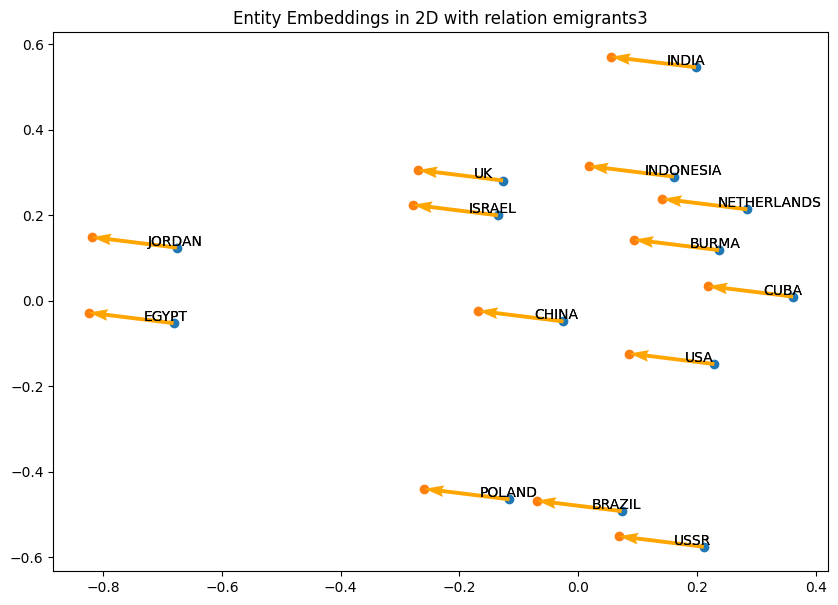

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

model = result.model

RELATION_SHOW_ID = 15

entity_embeddings = model.entity_representations[0]().detach().numpy()
relation_embeddings = model.relation_representations[0]().detach().numpy()

prediction_embeddings = entity_embeddings + relation_embeddings[RELATION_SHOW_ID]
entity_names = {v:k for k,v in dataset.entity_to_id.items()}
relation_names = {v:k for k,v in dataset.relation_to_id.items()}


pca = PCA(n_components=2)
entity_embeddings_plot = pca.fit_transform(entity_embeddings)
prediction_embeddings_plot = pca.transform(prediction_embeddings)

quiver_data = prediction_embeddings_plot - entity_embeddings_plot

plt.figure(figsize=(10,7))
plt.title(f"Entity Embeddings in 2D with relation {relation_names[RELATION_SHOW_ID]}")
plt.scatter(entity_embeddings_plot[:,0], entity_embeddings_plot[:,1], label='Entities')
plt.scatter(prediction_embeddings_plot[:,0], prediction_embeddings_plot[:,1], label="Predicted Entity")

for i, _ in enumerate(entity_embeddings_plot):
    plt.annotate(
        text=entity_names[i].upper(),
        xy=(entity_embeddings_plot[i,0] - 0.05, entity_embeddings_plot[i,1] + 0.005),
        fontsize=10
    )

for i, _ in enumerate(entity_embeddings_plot):
    plt.annotate(
        text=entity_names[i].upper(),
        xy=(entity_embeddings_plot[i,0] - 0.05, entity_embeddings_plot[i,1] + 0.005),
        fontsize=10
    )
    plt.quiver(entity_embeddings_plot[i,0], entity_embeddings_plot[i,1], quiver_data[i,0], quiver_data[i,1], angles='xy', scale_units='xy', scale=1, color='orange', width=0.005 )


# Hyperparameters Optimization

In [11]:
result = hpo_pipeline(
    n_trials=3,
    sampler='random',
    dataset=dataset,

    epochs=50,


    model='transe',
    model_kwargs_ranges=dict(
        embedding_dim=dict(type=int, low=2, high=5, q=1),
        entity_initializer=dict(type='categorical', choices=[
            'xavier_uniform',
            'xavier_uniform_norm',
            'uniform',
    ])),



    optimizer='adam',

    loss='marginranking',
    loss_kwargs_ranges = dict(
        margin=dict(type=float, low=1, high=2),
    ),

    training_loop='slcwa',


    evaluator='RankBasedEvaluator',
    evaluator_kwargs=dict(filtered=True),
    evaluation_kwargs=dict(batch_size=4),


    stopper='early',
    stopper_kwargs=dict(
        frequency=5,
        patience=2,
        relative_delta=0.002,
        ),


    negative_sampler='basic',
    device='cpu',  # Use 'cpu' or 'cuda'
)

[I 2025-05-28 13:19:19,970] A new study created in memory with name: no-name-0023b5db-48ed-4c27-adfd-13c460934179
INFO:pykeen.hpo.hpo:Using model: <class 'pykeen.models.unimodal.trans_e.TransE'>
INFO:pykeen.hpo.hpo:Using loss: <class 'pykeen.losses.MarginRankingLoss'>
INFO:pykeen.hpo.hpo:Using optimizer: <class 'torch.optim.adam.Adam'>
INFO:pykeen.hpo.hpo:Using training loop: <class 'pykeen.training.slcwa.SLCWATrainingLoop'>
INFO:pykeen.hpo.hpo:Using negative sampler: <class 'pykeen.sampling.basic_negative_sampler.BasicNegativeSampler'>
INFO:pykeen.hpo.hpo:Using evaluator: <class 'pykeen.evaluation.rank_based_evaluator.RankBasedEvaluator'>
INFO:pykeen.hpo.hpo:Attempting to maximize both.realistic.inverse_harmonic_mean_rank
INFO:pykeen.hpo.hpo:Filter validation triples when testing: True
INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.stoppers.early_stopping:Inferred checkpoint path for best model weights: /Users/navis/.data/pykeen/checkpoints/best-model-weights-f118780d-b75a-424

Training epochs on cpu:   0%|          | 0/50 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0/100 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/100 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/100 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0/100 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0/100 [00:00<?, ?batch/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.02s seconds
INFO:pykeen.stoppers.early_stopping:Stopping early at epoch 20. The best result 0.9723618090452262 occurred at epoch 10.
INFO:pykeen.stoppers.early_stopping:Re-loading weights from best epoch from /Users/navis/.data/pykeen/checkpoints/best-model-weights-ff554187-1b24-42fe-8e8d-a41914e18855.pt


Evaluating on cpu:   0%|          | 0.00/199 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.05s seconds
[I 2025-05-28 13:19:28,804] Trial 2 finished with value: 0.40869423747062683 and parameters: {'model.embedding_dim': 2, 'model.scoring_fct_norm': 1, 'model.entity_initializer': 'xavier_uniform', 'loss.margin': 1.1953052151247774, 'optimizer.lr': 0.04881466465763646, 'negative_sampler.num_negs_per_pos': 6, 'training.batch_size': 16}. Best is trial 0 with value: 0.41122254729270935.


In [ ]:
best_trial = result.study.best_trial

best_trial_params = {}
for param_name, param_value in best_trial.params.items():
    print(f"{param_name}: {param_value}")
    best_trial_params[param_name] = param_value

model.embedding_dim: 2
model.scoring_fct_norm: 2
model.entity_initializer: xavier_uniform_norm
loss.margin: 1.798736465778221
optimizer.lr: 0.09223574213417347
negative_sampler.num_negs_per_pos: 3
training.batch_size: 256
